# T15 — Driving the mantle with plate reconstructions

**Cluster E — Part 4, mantle scale.** Requires the container.

Every boundary condition in this suite so far has been invented. Free slip,
no slip, a prescribed velocity of one — all chosen because they are clean, none
because the Earth does them.

This notebook replaces the top boundary of T14's annulus with **surface
velocities from a plate reconstruction**. The mantle stops being a convecting
shell that happens to have a lid and becomes a mantle *driven by plates*, which
is the configuration most global mantle-flow studies actually use — and the
point at which this suite stops being a teaching exercise.

The reconstruction is [Müller et al.
(2022)](https://doi.org/10.5194/se-13-1127-2022), a billion-year model, read
with [pyGPlates](https://www.gplates.org/docs/pygplates/).

## Learning objectives

1. Extract surface velocities from a plate model along a great circle, and say what a cross-section throws away.
2. Convert cm/yr into the non-dimensional velocity a Boussinesq model expects, and sanity-check the number.
3. Recognise when a kinematic boundary condition removes a nullspace.
4. Diagnose an advection-dominated energy equation from the cell Péclet number before it produces nonsense.

## Prerequisites and runtime

* T03 (advection), T14 (the annulus). **Requires the container**, which carries
  pyGPlates and the reconstruction.
* **Measured runtime: about 8 minutes.**

In [1]:
# === USER CONFIGURATION ===
NCELLS, NLAYERS = 64, 16
RA = 1e5
STEPS = 200
AGES = (0.0, 100.0)        # Ma

In [2]:
import glob
import json
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting, plates as PL

DRIVER = os.path.join("..", "tools", "gadopt_annulus_case.py")

# The container carries the reconstruction at /opt/plate-model. Override with
# GEODYN_PLATE_DIR to point at your own copy.
PLATE_DIR = os.environ.get("GEODYN_PLATE_DIR", "/opt/plate-model")

ROT = sorted(glob.glob(f"{PLATE_DIR}/**/*.rot", recursive=True))
TOP = sorted(glob.glob(f"{PLATE_DIR}/**/*.gpml", recursive=True)
             + glob.glob(f"{PLATE_DIR}/**/*.gpmlz", recursive=True))
print(f"reconstruction at {PLATE_DIR}: {len(ROT)} rotation file(s), "
      f"{len(TOP)} topology files")


def run(tag, age=None, su=True, steps=STEPS, **kw):
    cmd = [sys.executable, DRIVER, "--ncells", str(NCELLS),
           "--nlayers", str(NLAYERS), "--ra", str(RA), "--tol", "0",
           "--max-steps", str(steps), "--out", f"{tag}.npz"]
    if age is not None:
        cmd += ["--plate-dir", PLATE_DIR, "--plate-age", str(age)]
    if su:
        cmd += ["--su"]
    for k, v in kw.items():
        cmd += [f"--{k.replace('_', '-')}", str(v)]
    p = subprocess.run(cmd, capture_output=True, text=True)
    for line in p.stdout.splitlines():
        if line.startswith("RESULT "):
            return json.loads(line[len("RESULT "):])
    raise RuntimeError(f"no result:\n{p.stderr[-1500:]}")

reconstruction at /opt/plate-model: 1 rotation file(s), 7 topology files


## 1. A cross-section keeps one component and throws the other away

An annulus is a slice through the Earth, so driving one with plate motions means
choosing a **great circle** and sampling the plate model along it. The default
here is the equator.

Plate velocity is a vector on a sphere. The section has one direction. So there
is a decision to make about the component perpendicular to the slice, and it is
a modelling decision rather than a detail:

**Only the in-plane component is kept.** Out-of-plane motion is discarded, not
projected or averaged. A plate moving obliquely to the section therefore appears
to converge less than it really does. Choose the circle so the tectonics you
care about is roughly in-plane, and read any comparison against a 3-D model in
that light.

This is also why G-ADOPT's own `GplatesVelocityFunction` is not used here: it
assumes a three-dimensional spherical shell, seeds a Fibonacci sphere and works
in (latitude, longitude). An annulus has one angular coordinate, so
`geodynkit.plates` does the sampling instead, in about eighty lines.

## 2. Velocities out of a reconstruction

In [3]:
theta = np.linspace(0.0, 360.0, 181)
prof = PL.surface_velocity_profile(ROT, TOP, 0.0, theta)
v = prof["velocity_cm_yr"]
pid = prof["plate_id"]
bnd = theta[:-1][np.diff(pid) != 0]

print(f"equator at 0 Ma: {len(set(pid))} plates crossed, "
      f"{len(bnd)} boundaries")
print(f"in-plane speed {v.min():+.2f} to {v.max():+.2f} cm/yr")
for name, p in (("Pacific", 901), ("South America", 201),
                ("Africa", 701), ("Eurasia", 301)):
    sel = pid == p
    if sel.any():
        print(f"  plate {p:>4} ({name:<14}) spans "
              f"{100 * sel.mean():5.1f}% of the section, "
              f"mean in-plane {v[sel].mean():+.2f} cm/yr")

equator at 0 Ma: 13 plates crossed, 13 boundaries
in-plane speed -7.42 to +7.22 cm/yr
  plate  901 (Pacific       ) spans  29.8% of the section, mean in-plane -6.51 cm/yr
  plate  201 (South America ) spans  15.5% of the section, mean in-plane -0.47 cm/yr
  plate  701 (Africa        ) spans  15.5% of the section, mean in-plane +2.82 cm/yr
  plate  301 (Eurasia       ) spans   5.0% of the section, mean in-plane +2.36 cm/yr


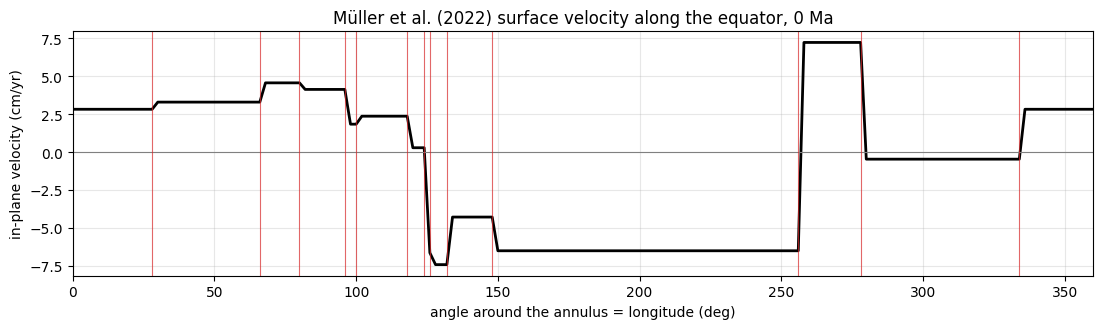

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(theta, v, "k-", lw=2)
ax.axhline(0, color="0.5", lw=0.8)
for b in bnd:
    ax.axvline(b, color="C3", lw=0.8, alpha=0.7)
ax.set(xlabel="angle around the annulus = longitude (deg)",
       ylabel="in-plane velocity (cm/yr)",
       title="Müller et al. (2022) surface velocity along the equator, 0 Ma",
       xlim=(0, 360))
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

The red lines are plate boundaries — places where the plate id changes along the
section. The velocity is piecewise smooth between them and jumps across them,
which is exactly what a plate model is: rigid pieces with all the deformation at
the edges.

Where the velocity steps **down** going left to right, the section is
convergent; where it steps **up**, divergent. Those are the places the mantle
below should respond to.

## 3. What 1 cm/yr is worth

The Boussinesq annulus is non-dimensionalised with the velocity scale
$\kappa / L$, so a dimensional speed becomes $u^* = u L / \kappa$ with
$L = 2890$ km and $\kappa = 10^{-6}$ m²/s. Do that arithmetic before running
anything:

In [5]:
print(f"1 cm/yr  -> {PL.nondimensionalise_velocity(1.0):8.0f} non-dimensional")
print(f"peak plate speed here ({np.abs(v).max():.1f} cm/yr) -> "
      f"{PL.nondimensionalise_velocity(np.abs(v).max()):8.0f}")
print(f"free-slip annulus at Ra = {RA:.0e} convects at u_rms ~ 193 (T14)")
print(f"\nratio: the surface drives {PL.nondimensionalise_velocity(np.abs(v).max()) / 193:.0f}x "
      "harder than the interior convects")

1 cm/yr  ->      916 non-dimensional
peak plate speed here (7.4 cm/yr) ->     6802
free-slip annulus at Ra = 1e+05 convects at u_rms ~ 193 (T14)

ratio: the surface drives 35x harder than the interior convects


**The surface wins by more than an order of magnitude.** That is not a mistake
in the setup; it is what plate-driven flow means at this Rayleigh number. But it
is worth being explicit that buoyancy is close to a passenger here: Earth's
mantle runs at $Ra \sim 10^7$–$10^8$, where convective velocities are comparable
to plate speeds and the two genuinely compete. At $10^5$ they do not.

Anyone reading a plate-driven mantle model should ask this question of it, and
the answer is one line of arithmetic.

## 4. Imposing the plates, and the nullspace that disappears

T14's surface was free slip: normal velocity zero, tangential stress zero, the
interior free to move the surface however it liked. Now the **full velocity
vector** is prescribed — normal component zero, tangential component from the
reconstruction.

One consequence is easy to miss. T14 had to declare a **rotational nullspace**
because a closed annulus with free-slip boundaries can spin at no cost. Pin the
surface velocity and it cannot: the nullspace is gone, and declaring it anyway
would project out part of a solution that is now perfectly physical.

```python
rotational = plate_profile is None
ns = create_stokes_nullspace(Z, closed=True, rotational=rotational)
```

## 5. Cell Péclet, and T03 arriving in a real model

Before running, one more number. The cell Péclet number is $u h / \kappa$, which
non-dimensionally is just $u \, h$:

In [6]:
h = 1.0 / NLAYERS
for label, u in (("free slip (T14)", 193), ("plate driven", 2000)):
    print(f"{label:>18}: u ~ {u:5.0f}, h = {h:.4f}  ->  cell Peclet {u * h:6.1f}")

   free slip (T14): u ~   193, h = 0.0625  ->  cell Peclet   12.1
      plate driven: u ~  2000, h = 0.0625  ->  cell Peclet  125.0


Twelve is borderline and plain Galerkin copes. **A hundred and twenty-five does
not.** Here is what that looks like:

In [7]:
# Both at the full step count: the oscillation grows with the shear, and a
# short run understates it badly (0.2% of the domain at 60 steps against
# 2.5% at 200).
no_su = run("plate_nosu", age=0.0, su=False)
with_su = run("plate_su_ref", age=0.0, su=True)
print(f"{'':>14} {'T min':>9} {'T max':>9} {'outside [0,1]':>15} {'seconds':>9}")
for name, r in (("plain Galerkin", no_su), ("streamline-upwind", with_su)):
    print(f"{name:>14} {r['T_min']:>9.4f} {r['T_max']:>9.4f} "
          f"{100 * r['T_out_of_bounds']:>14.1f}% {r['seconds']:>9.1f}")

                   T min     T max   outside [0,1]   seconds
plain Galerkin   -0.4394    0.9957            2.5%     113.4
streamline-upwind    0.0032    0.9960            0.0%     116.5


Temperature is a normalised quantity bounded by its boundary conditions: it
cannot be negative. Plain Galerkin drives it well below zero over a few percent
of the domain — the classic dispersive overshoot of an under-resolved advection
term, and precisely the failure T03 demonstrated on a 1-D pulse.

Streamline-upwind stabilisation removes it at no measurable cost in time. The
cost is elsewhere, and T03 named that too: **numerical diffusion along the
flow**, which is what damps the oscillation and what smears a sharp thermal
front. On this mesh that is a bargain. On a mesh fine enough to resolve a slab,
it might not be.

## 6. Two ages, two mantles

In [8]:
res = {age: run(f"plate_{int(age)}", age=age, su=True) for age in AGES}
print(f"{'age':>6} {'peak cm/yr':>11} {'u_rms':>9} {'Nu top':>8} {'Nu base':>9} {'T range':>18}")
for age, r in res.items():
    d = np.load(f"plate_{int(age)}.npz")
    pk = np.abs(d["plate_velocity_cm_yr"]).max()
    print(f"{age:>6.0f} {pk:>11.2f} {r['u_rms']:>9.0f} {r['nu_top']:>8.2f} "
          f"{r['nu_base']:>9.2f} {r['T_min']:>8.3f} to {r['T_max']:>5.3f}")

   age  peak cm/yr     u_rms   Nu top   Nu base            T range
     0        7.42      1982    13.44     10.00    0.003 to 0.996
   100        9.08      1867     5.90     13.79    0.001 to 0.997


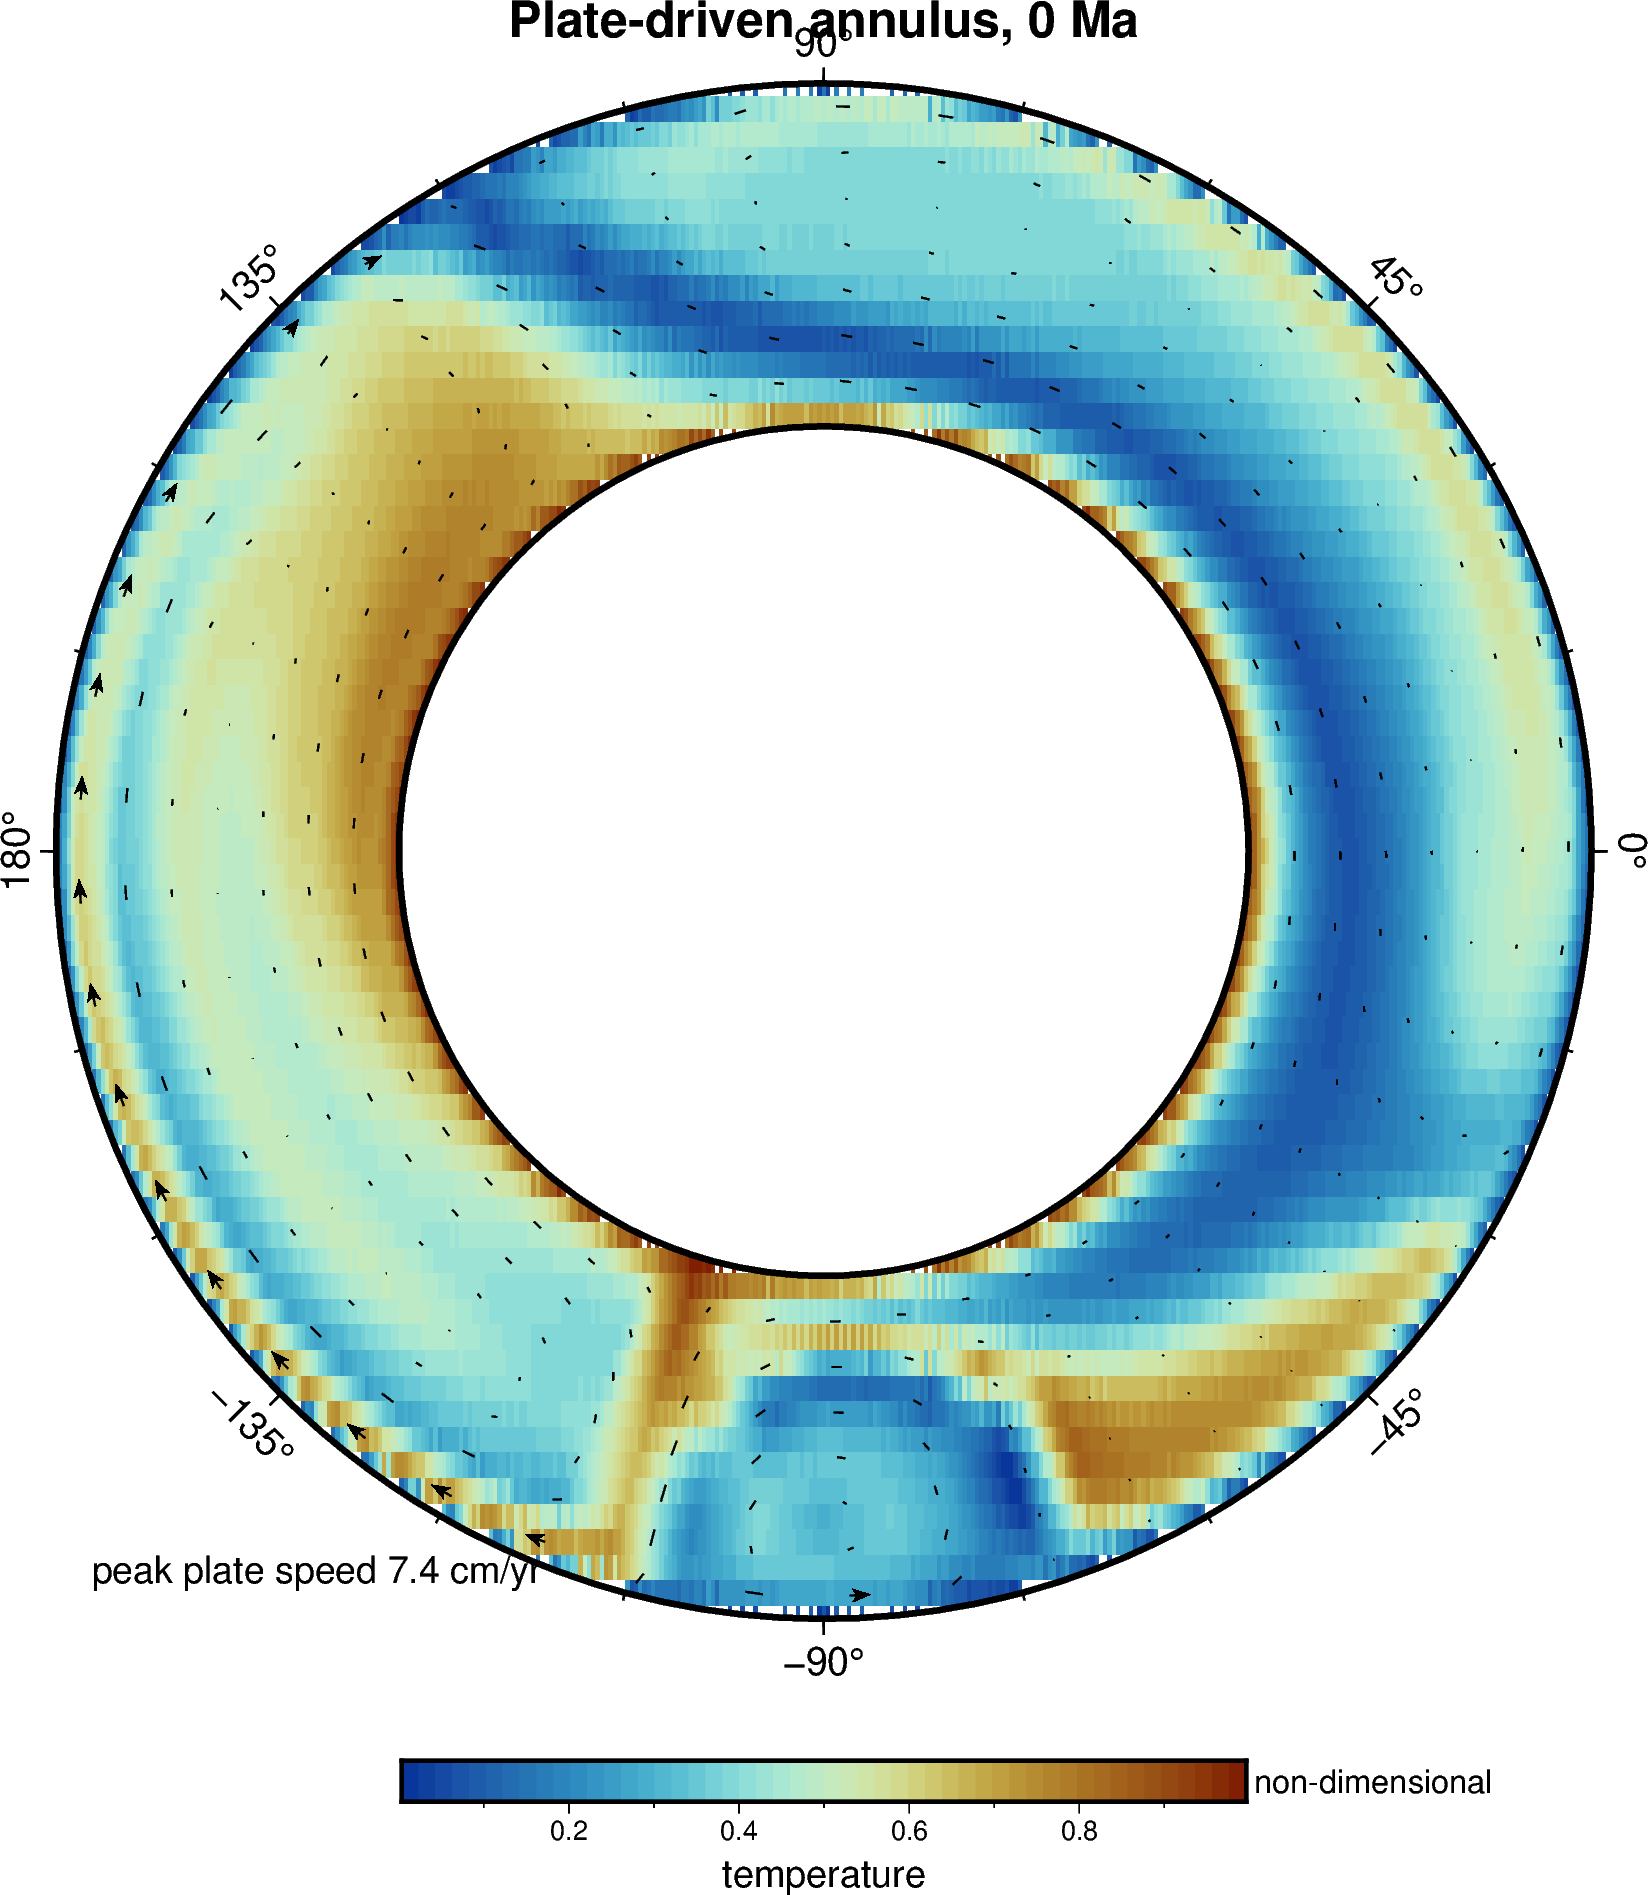

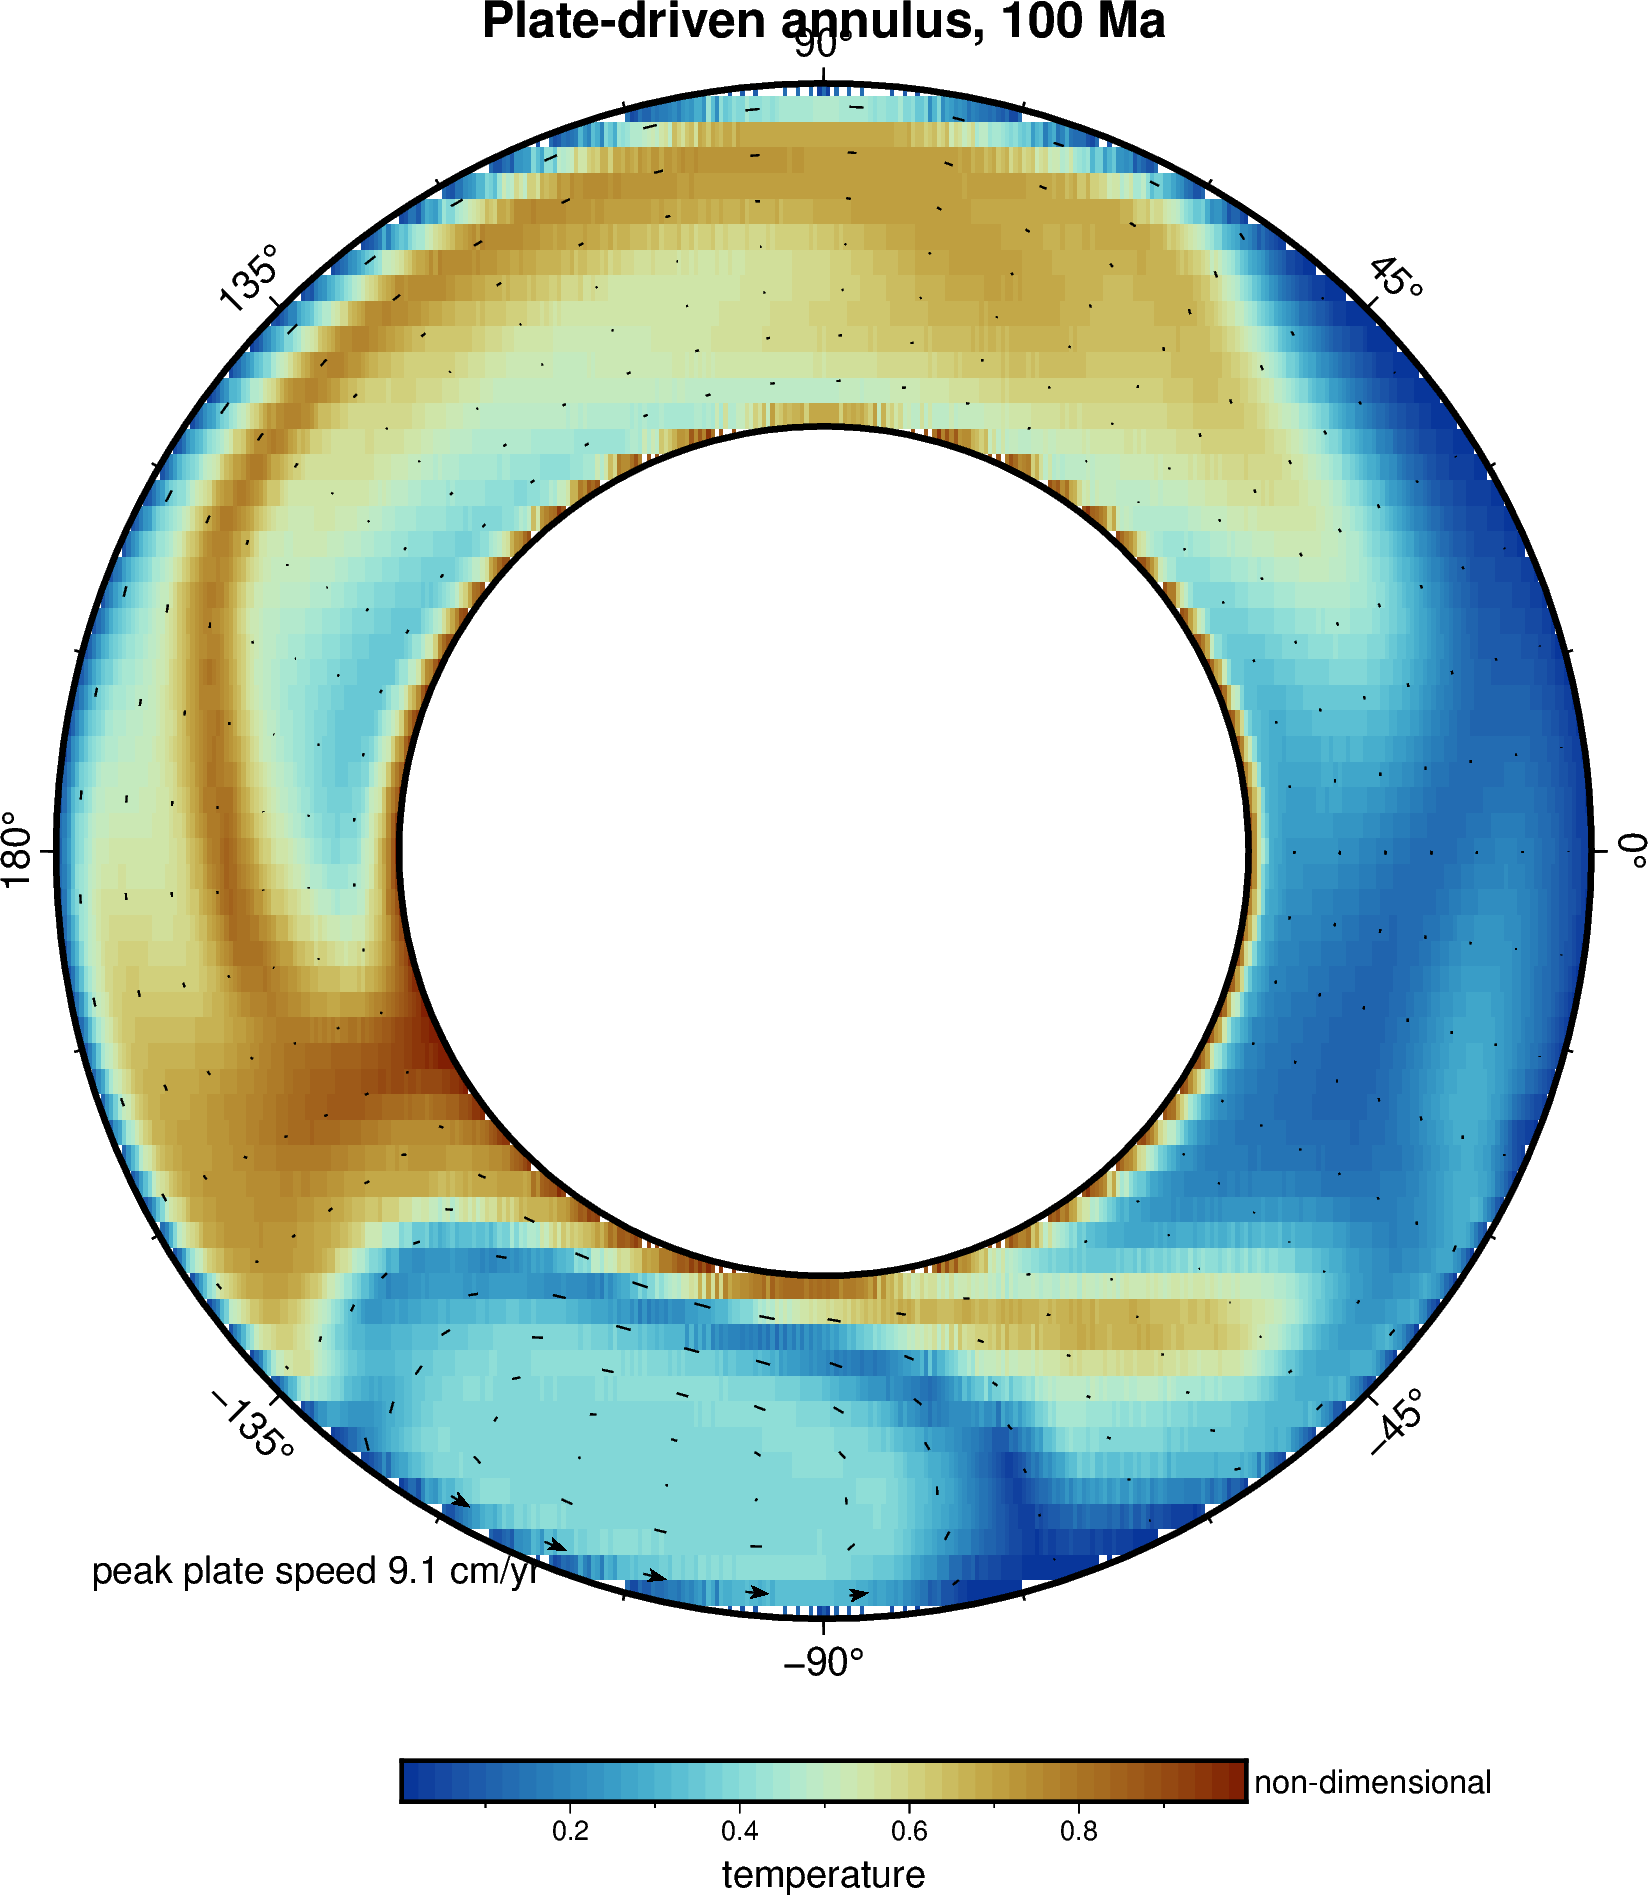

In [9]:
for age in AGES:
    d = np.load(f"plate_{int(age)}.npz")
    fig = plotting.annulus_panel(
        d["temperature"], d["theta_deg"], d["radius"], kind="temperature",
        title=f"Plate-driven annulus, {age:.0f} Ma", label="temperature",
        unit="non-dimensional", u_r=d["u_r"], u_theta=d["u_theta"],
        every=8, width_cm=13.0, arrow_cm=0.5,
        stamp=f"peak plate speed {np.abs(d['plate_velocity_cm_yr']).max():.1f} cm/yr",
    )
    fig.show()

The surface has sheared the thermal field into spirals, and the two ages differ
because the plate configuration differs — at 100 Ma the peak in-plane speed is
higher and the boundaries are in different places, so the downwellings are too.

Be careful what you claim from these. The **flow** is instantaneous: Stokes has
no memory, so the velocity field is fully determined by the plates and the
current buoyancy. The **thermal structure** is not — 200 steps covers a model
time of about 0.003, against the 0.17 T14 needed to reach steady state. What you
are seeing is the flow the plates drive through a thermal field that has barely
begun to respond, which is a legitimate thing to look at and is not a
reconstruction of the mantle at 100 Ma.

## 7. What research use would need

Four things, in rough order of importance:

1. **Three dimensions.** The out-of-plane component thrown away in section 1 is not small for most plates, and slabs are not two-dimensional.
2. **A realistic Rayleigh number.** At $10^5$ the surface out-drives the interior thirty-five to one; at Earth's $10^7$–$10^8$ they compete, which is the regime where the interesting questions live.
3. **Time-dependent boundary conditions.** The plates here are frozen at one age. A real reconstruction run updates the surface velocity every step and integrates through geological time — which is what G-ADOPT's `GplatesVelocityFunction` does for the 3-D case.
4. **Something to compare against.** Seismic tomography is the usual target, and the comparison is what makes the exercise science rather than an illustration.

None of those is a change of method. They are changes of scale, and the machinery
in this notebook is the machinery they would use.

## Extend this

* Change the great circle. `pole_lat=0, pole_lon=90` gives a section through the poles; a circle down the Pacific gives a very different velocity profile. Which sections are most nearly in-plane?
* Sweep the age from 0 to 200 Ma in 20 Ma steps and plot peak in-plane speed against age. Does the model's plate motion speed up or slow down?
* Raise `RA` to 1e6 and re-run at 128×32. At what Rayleigh number does the interior stop being a passenger?
* Run the 0 Ma case for 2000 steps and watch whether downwellings organise beneath the convergent boundaries identified in section 2.
* Compare the free-slip Nusselt ratio check from T14 against these runs. Why does it no longer hold, and what would replace it?